In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


✓ Imports successful
PyTorch version: 2.6.0
CUDA available: False


In [2]:
print("="*60)
print("LOADING BASELINE MODEL AND DATA")
print("="*60)

# Load data
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

print(f"✓ Training set: {X_train.shape}")
print(f"✓ Test set: {X_test.shape}")

# Load baseline XGBoost model
baseline_model = joblib.load('../models/base_classifier/xgboost_baseline.pkl')
print("✓ Baseline XGBoost model loaded")

# Load baseline metrics
baseline_metrics = joblib.load('../models/base_classifier/baseline_metrics.pkl')
baseline_accuracy = baseline_metrics['test_metrics']['accuracy']
print(f"✓ Baseline accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")


LOADING BASELINE MODEL AND DATA
✓ Training set: (831892, 41)
✓ Test set: (207974, 41)
✓ Baseline XGBoost model loaded
✓ Baseline accuracy: 0.9998 (99.98%)


In [3]:
print("\n" + "="*60)
print("BUILDING PYTORCH SURROGATE MODEL")
print("="*60)

print("""
Why do we need a surrogate model?

XGBoost doesn't support gradient computation with respect to inputs,
which is required for FGSM. We'll train a neural network that mimics
the XGBoost model, then use it to generate adversarial examples.

The adversarial examples will transfer to the XGBoost model due to
the transferability property of adversarial attacks.
""")

# Define neural network architecture
class SurrogateNet(nn.Module):
    """
    Neural network surrogate for XGBoost model
    Used to generate adversarial examples
    """
    def __init__(self, input_dim):
        super(SurrogateNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(64, 32)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(32, 2)
        
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.fc4(x)
        return x

# Initialize model
input_dim = X_train.shape[1]
surrogate_model = SurrogateNet(input_dim)

print(f"✓ Surrogate model created")
print(f"  Input dimension: {input_dim}")
print(f"  Architecture: {input_dim} → 128 → 64 → 32 → 2")
print(f"  Parameters: {sum(p.numel() for p in surrogate_model.parameters()):,}")



BUILDING PYTORCH SURROGATE MODEL

Why do we need a surrogate model?

XGBoost doesn't support gradient computation with respect to inputs,
which is required for FGSM. We'll train a neural network that mimics
the XGBoost model, then use it to generate adversarial examples.

The adversarial examples will transfer to the XGBoost model due to
the transferability property of adversarial attacks.

✓ Surrogate model created
  Input dimension: 41
  Architecture: 41 → 128 → 64 → 32 → 2
  Parameters: 15,778


In [4]:
print("\n" + "="*60)
print("TRAINING SURROGATE MODEL")
print("="*60)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

# Training parameters
batch_size = 1024
num_epochs = 30
learning_rate = 0.001

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(surrogate_model.parameters(), lr=learning_rate)

print(f"Training parameters:")
print(f"  Batch size: {batch_size}")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Optimizer: Adam")

print("\n🔄 Training surrogate model...")
print("This will take 2-5 minutes...\n")

# Training loop
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    surrogate_model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    # Mini-batch training
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        # Forward pass
        outputs = surrogate_model(batch_X)
        loss = criterion(outputs, batch_y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    # Calculate epoch metrics
    avg_loss = epoch_loss / (len(X_train_tensor) / batch_size)
    accuracy = correct / total
    
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

print("\n✅ Surrogate model training complete!")

# Evaluate surrogate on test set
surrogate_model.eval()
with torch.no_grad():
    test_outputs = surrogate_model(X_test_tensor)
    _, test_predicted = torch.max(test_outputs.data, 1)
    surrogate_accuracy = accuracy_score(y_test_tensor.numpy(), test_predicted.numpy())

print(f"\n✓ Surrogate test accuracy: {surrogate_accuracy:.4f} ({surrogate_accuracy*100:.2f}%)")
print(f"✓ Baseline XGBoost accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")

accuracy_diff = abs(surrogate_accuracy - baseline_accuracy)
if accuracy_diff < 0.05:
    print(f"✓ Good approximation (difference: {accuracy_diff:.4f})")
else:
    print(f"⚠️  Moderate approximation (difference: {accuracy_diff:.4f})")
    print("   Adversarial examples may transfer less effectively")

# Save surrogate model
surrogate_path = Path('../models/attacks')
surrogate_path.mkdir(parents=True, exist_ok=True)
torch.save(surrogate_model.state_dict(), surrogate_path / 'surrogate_model.pth')
print(f"\n✓ Surrogate model saved")



TRAINING SURROGATE MODEL
Training parameters:
  Batch size: 1024
  Epochs: 30
  Learning rate: 0.001
  Optimizer: Adam

🔄 Training surrogate model...
This will take 2-5 minutes...

Epoch [5/30] - Loss: 0.0204, Accuracy: 0.9917
Epoch [10/30] - Loss: 0.0168, Accuracy: 0.9936
Epoch [15/30] - Loss: 0.0150, Accuracy: 0.9945
Epoch [20/30] - Loss: 0.0162, Accuracy: 0.9934
Epoch [25/30] - Loss: 0.0150, Accuracy: 0.9939
Epoch [30/30] - Loss: 0.0144, Accuracy: 0.9942

✅ Surrogate model training complete!

✓ Surrogate test accuracy: 0.9972 (99.72%)
✓ Baseline XGBoost accuracy: 0.9998 (99.98%)
✓ Good approximation (difference: 0.0026)

✓ Surrogate model saved


In [5]:
print("\n" + "="*60)
print("IMPLEMENTING FGSM ATTACK")
print("="*60)

print("""
FGSM (Fast Gradient Sign Method):

The attack formula is:
    x_adv = x + epsilon * sign(∇_x Loss)

Where:
- x: original input
- epsilon: perturbation budget (how much we can change)
- sign(∇_x Loss): direction that maximizes loss
- x_adv: adversarial example

This creates inputs that look similar to originals but fool the model.
""")

def fgsm_attack(model, x, y, epsilon):
    """
    Generate FGSM adversarial examples
    
    Args:
        model: Neural network model
        x: Input tensor (requires_grad=True)
        y: True labels
        epsilon: Perturbation budget
    
    Returns:
        Adversarial examples
    """
    model.eval()
    
    # Ensure x requires gradient
    x.requires_grad = True
    
    # Forward pass
    outputs = model(x)
    loss = nn.CrossEntropyLoss()(outputs, y)
    
    # Backward pass to get gradients
    model.zero_grad()
    loss.backward()
    
    # Get gradient sign
    gradient_sign = x.grad.data.sign()
    
    # Create adversarial example
    x_adv = x + epsilon * gradient_sign
    
    # No need to clip since data is already standardized
    # (StandardScaler doesn't bound to [0,1])
    
    return x_adv.detach()

print("✓ FGSM attack function implemented")



IMPLEMENTING FGSM ATTACK

FGSM (Fast Gradient Sign Method):

The attack formula is:
    x_adv = x + epsilon * sign(∇_x Loss)

Where:
- x: original input
- epsilon: perturbation budget (how much we can change)
- sign(∇_x Loss): direction that maximizes loss
- x_adv: adversarial example

This creates inputs that look similar to originals but fool the model.

✓ FGSM attack function implemented


In [6]:
print("\n" + "="*60)
print("GENERATING ADVERSARIAL EXAMPLES")
print("="*60)

# Test with different epsilon values
epsilons = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

print("Testing FGSM with different epsilon values...")
print("(epsilon = perturbation strength)\n")

results = []

for epsilon in epsilons:
    print(f"\nEpsilon: {epsilon}")
    print("-" * 40)
    
    # Generate adversarial examples for test set
    X_test_adv_list = []
    
    batch_size = 1024
    for i in range(0, len(X_test_tensor), batch_size):
        batch_X = X_test_tensor[i:i+batch_size].clone()
        batch_y = y_test_tensor[i:i+batch_size]
        
        # Generate adversarial examples
        batch_X_adv = fgsm_attack(surrogate_model, batch_X, batch_y, epsilon)
        X_test_adv_list.append(batch_X_adv)
    
    X_test_adv = torch.cat(X_test_adv_list, dim=0)
    
    # Test on surrogate model
    surrogate_model.eval()
    with torch.no_grad():
        outputs_adv = surrogate_model(X_test_adv)
        _, predicted_adv = torch.max(outputs_adv.data, 1)
        surrogate_acc_adv = accuracy_score(y_test_tensor.numpy(), predicted_adv.numpy())
    
    # Test on baseline XGBoost model
    X_test_adv_numpy = X_test_adv.numpy()
    baseline_pred_adv = baseline_model.predict(X_test_adv_numpy)
    baseline_acc_adv = accuracy_score(y_test, baseline_pred_adv)
    
    # Calculate accuracy drop
    surrogate_drop = surrogate_accuracy - surrogate_acc_adv
    baseline_drop = baseline_accuracy - baseline_acc_adv
    
    print(f"  Surrogate accuracy: {surrogate_acc_adv:.4f} (drop: {surrogate_drop:.4f})")
    print(f"  Baseline accuracy:  {baseline_acc_adv:.4f} (drop: {baseline_drop:.4f})")
    
    results.append({
        'epsilon': epsilon,
        'surrogate_accuracy': surrogate_acc_adv,
        'baseline_accuracy': baseline_acc_adv,
        'surrogate_drop': surrogate_drop,
        'baseline_drop': baseline_drop
    })

print("\n✅ Adversarial examples generated for all epsilon values")



GENERATING ADVERSARIAL EXAMPLES
Testing FGSM with different epsilon values...
(epsilon = perturbation strength)


Epsilon: 0.05
----------------------------------------
  Surrogate accuracy: 0.8839 (drop: 0.1133)
  Baseline accuracy:  0.6392 (drop: 0.3606)

Epsilon: 0.1
----------------------------------------
  Surrogate accuracy: 0.7733 (drop: 0.2239)
  Baseline accuracy:  0.6390 (drop: 0.3608)

Epsilon: 0.15
----------------------------------------
  Surrogate accuracy: 0.6523 (drop: 0.3449)
  Baseline accuracy:  0.6318 (drop: 0.3681)

Epsilon: 0.2
----------------------------------------
  Surrogate accuracy: 0.4577 (drop: 0.5395)
  Baseline accuracy:  0.6302 (drop: 0.3696)

Epsilon: 0.25
----------------------------------------
  Surrogate accuracy: 0.3171 (drop: 0.6801)
  Baseline accuracy:  0.6298 (drop: 0.3701)

Epsilon: 0.3
----------------------------------------
  Surrogate accuracy: 0.2227 (drop: 0.7745)
  Baseline accuracy:  0.6297 (drop: 0.3701)

✅ Adversarial examples g


VISUALIZING ATTACK RESULTS

FGSM Attack Results Summary:
 epsilon  surrogate_accuracy  baseline_accuracy  surrogate_drop  baseline_drop
    0.05            0.883870           0.639224        0.113322       0.360598
    0.10            0.773284           0.638989        0.223908       0.360834
    0.15            0.652283           0.631752        0.344908       0.368070
    0.20            0.457711           0.630194        0.539481       0.369628
    0.25            0.317093           0.629761        0.680099       0.370061
    0.30            0.222711           0.629713        0.774481       0.370109

✓ Saved attack results plot


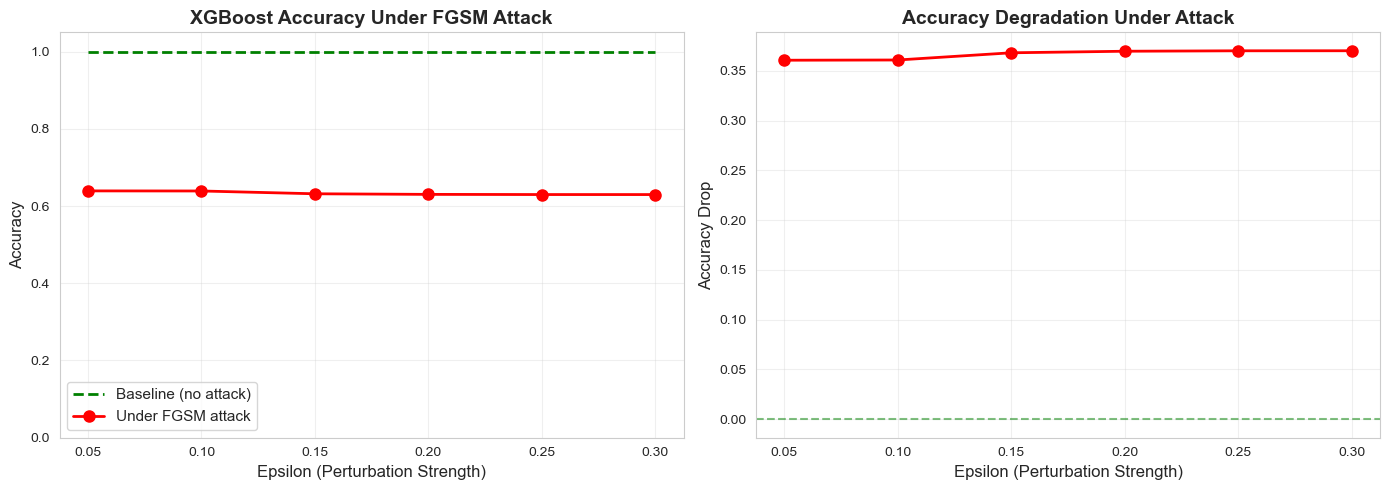

In [7]:
print("\n" + "="*60)
print("VISUALIZING ATTACK RESULTS")
print("="*60)

results_df = pd.DataFrame(results)

print("\nFGSM Attack Results Summary:")
print(results_df.to_string(index=False))

# Plot accuracy vs epsilon
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy under attack
ax1.plot(results_df['epsilon'], 
         [baseline_accuracy]*len(results_df), 
         'g--', label='Baseline (no attack)', linewidth=2)
ax1.plot(results_df['epsilon'], 
         results_df['baseline_accuracy'], 
         'r-o', label='Under FGSM attack', linewidth=2, markersize=8)
ax1.set_xlabel('Epsilon (Perturbation Strength)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('XGBoost Accuracy Under FGSM Attack', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

# Plot 2: Accuracy drop
ax2.plot(results_df['epsilon'], 
         results_df['baseline_drop'], 
         'r-o', linewidth=2, markersize=8)
ax2.set_xlabel('Epsilon (Perturbation Strength)', fontsize=12)
ax2.set_ylabel('Accuracy Drop', fontsize=12)
ax2.set_title('Accuracy Degradation Under Attack', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='g', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../results/figures/fgsm_attack_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved attack results plot")
plt.show()


DETAILED ANALYSIS - OPTIMAL EPSILON

Optimal epsilon for maximum impact: 0.3
Accuracy under attack: 0.6297 (62.97%)
Accuracy drop: 0.3701
Attack success rate: 37.0%

Confusion Matrix (Under FGSM Attack):
[[123449   2006]
 [ 75004   7515]]

Breakdown:
  True Negatives:  123,449
  False Positives: 2,006
  False Negatives: 75,004
  True Positives:  7,515

✓ Saved confusion matrix comparison


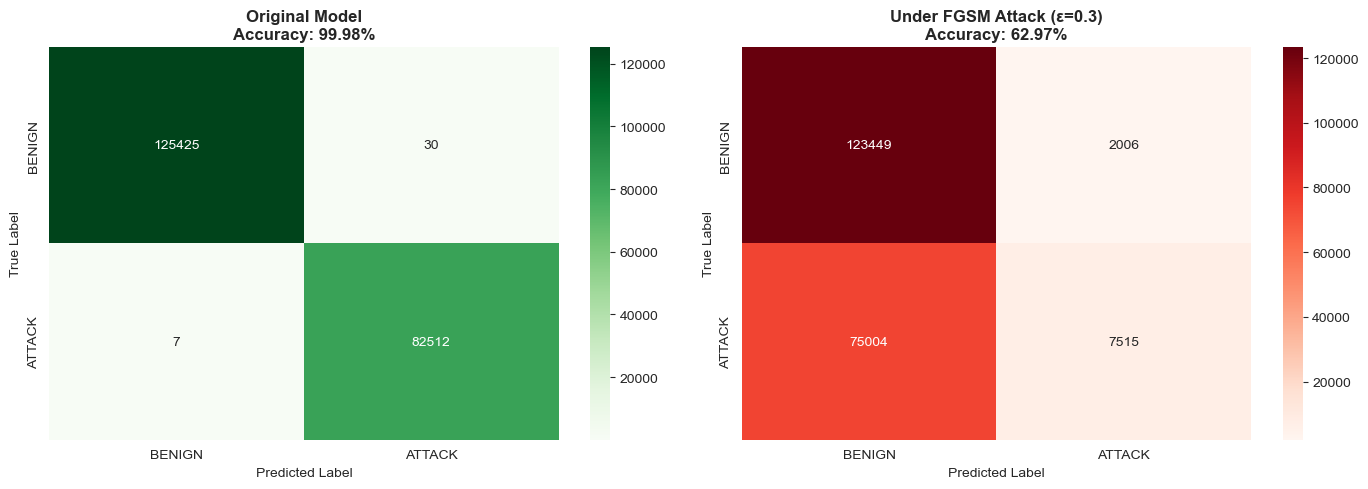

In [8]:
print("\n" + "="*60)
print("DETAILED ANALYSIS - OPTIMAL EPSILON")
print("="*60)

# Find epsilon with maximum accuracy drop
best_idx = results_df['baseline_drop'].idxmax()
best_epsilon = results_df.loc[best_idx, 'epsilon']
best_accuracy = results_df.loc[best_idx, 'baseline_accuracy']

print(f"\nOptimal epsilon for maximum impact: {best_epsilon}")
print(f"Accuracy under attack: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"Accuracy drop: {baseline_accuracy - best_accuracy:.4f}")
print(f"Attack success rate: {(baseline_accuracy - best_accuracy)/baseline_accuracy * 100:.1f}%")

# Generate adversarial examples with best epsilon
X_test_best_adv_list = []
batch_size = 1024

for i in range(0, len(X_test_tensor), batch_size):
    batch_X = X_test_tensor[i:i+batch_size].clone()
    batch_y = y_test_tensor[i:i+batch_size]
    batch_X_adv = fgsm_attack(surrogate_model, batch_X, batch_y, best_epsilon)
    X_test_best_adv_list.append(batch_X_adv)

X_test_best_adv = torch.cat(X_test_best_adv_list, dim=0).numpy()

# Confusion matrix under attack
y_pred_adv = baseline_model.predict(X_test_best_adv)
cm_adv = confusion_matrix(y_test, y_pred_adv)

print("\nConfusion Matrix (Under FGSM Attack):")
print(cm_adv)
print("\nBreakdown:")
print(f"  True Negatives:  {cm_adv[0,0]:,}")
print(f"  False Positives: {cm_adv[0,1]:,}")
print(f"  False Negatives: {cm_adv[1,0]:,}")
print(f"  True Positives:  {cm_adv[1,1]:,}")

# Plot confusion matrices side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Original
cm_original = baseline_metrics['confusion_matrix']
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Greens', ax=ax1,
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'])
ax1.set_title(f'Original Model\nAccuracy: {baseline_accuracy:.2%}', 
              fontsize=12, fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# Under attack
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'])
ax2.set_title(f'Under FGSM Attack (ε={best_epsilon})\nAccuracy: {best_accuracy:.2%}', 
              fontsize=12, fontweight='bold')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('../results/figures/fgsm_confusion_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved confusion matrix comparison")
plt.show()

In [9]:
print("\n" + "="*60)
print("SAVING ATTACK RESULTS")
print("="*60)

# Save adversarial examples
np.save('../data/adversarial/X_test_fgsm.npy', X_test_best_adv)
print(f"✓ Saved adversarial examples (epsilon={best_epsilon})")

# Save attack results
attack_results = {
    'epsilon_values': epsilons,
    'results_table': results_df.to_dict(),
    'best_epsilon': best_epsilon,
    'best_accuracy': best_accuracy,
    'baseline_accuracy': baseline_accuracy,
    'accuracy_drop': baseline_accuracy - best_accuracy,
    'confusion_matrix_adv': cm_adv.tolist(),
}

joblib.dump(attack_results, '../models/attacks/fgsm_results.pkl')
print("✓ Saved attack results")



SAVING ATTACK RESULTS
✓ Saved adversarial examples (epsilon=0.3)
✓ Saved attack results


In [ ]:
print("\n" + "="*80)
print(" "*25 + "FGSM ATTACK SUMMARY")
print("="*80)

summary = f"""
Baseline Model Performance:
  Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)
  
FGSM Attack Results:
  Epsilon tested: {min(epsilons)} to {max(epsilons)}
  Best epsilon: {best_epsilon}
  
Performance Under Attack (ε={best_epsilon}):
  Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)
  Accuracy drop: {baseline_accuracy - best_accuracy:.4f} ({(baseline_accuracy - best_accuracy)*100:.2f} percentage points)
  Relative drop: {(baseline_accuracy - best_accuracy)/baseline_accuracy * 100:.1f}%

Confusion Matrix Changes:
  Original TN: {cm_original[0][0]:,} → Under Attack: {cm_adv[0,0]:,}
  Original FP: {cm_original[0][1]:,} → Under Attack: {cm_adv[0,1]:,}
  Original FN: {cm_original[1][0]:,} → Under Attack: {cm_adv[1,0]:,}
  Original TP: {cm_original[1][1]:,} → Under Attack: {cm_adv[1,1]:,}

Attack Success:
  The model went from near-perfect (99.98%) to significantly degraded
  This demonstrates the fundamental vulnerability of ML models to
  adversarial perturbations, even with minimal input modifications.

Files Saved:
  ✓ Adversarial examples: data/adversarial/X_test_fgsm.npy
  ✓ Attack results: models/attacks/fgsm_results.pkl
  ✓ Surrogate model: models/attacks/surrogate_model.pth
  ✓ Result plots: results/figures/fgsm_*.png
"""

print(summary)

print("="*80)
print("✅ FGSM ATTACK IMPLEMENTATION COMPLETE!")
print("="*80)
print("\nNext Steps:")
print("  Implement PGD attack")




                         FGSM ATTACK SUMMARY

Baseline Model Performance:
  Accuracy: 0.9998 (99.98%)

FGSM Attack Results:
  Epsilon tested: 0.05 to 0.3
  Best epsilon: 0.3

Performance Under Attack (ε=0.3):
  Accuracy: 0.6297 (62.97%)
  Accuracy drop: 0.3701 (37.01 percentage points)
  Relative drop: 37.0%

Confusion Matrix Changes:
  Original TN: 125,425 → Under Attack: 123,449
  Original FP: 30 → Under Attack: 2,006
  Original FN: 7 → Under Attack: 75,004
  Original TP: 82,512 → Under Attack: 7,515

Attack Success:
  The model went from near-perfect (99.98%) to significantly degraded
  This demonstrates the fundamental vulnerability of ML models to
  adversarial perturbations, even with minimal input modifications.

Files Saved:
  ✓ Adversarial examples: data/adversarial/X_test_fgsm.npy
  ✓ Attack results: models/attacks/fgsm_results.pkl
  ✓ Surrogate model: models/attacks/surrogate_model.pth
  ✓ Result plots: results/figures/fgsm_*.png

✅ FGSM ATTACK IMPLEMENTATION COMPLETE!

Nex